# Formulacion QUBO (nucleo canonico)
## ISLA VERDE 2.0 · Challenge 1 · Quantathon CR 2026

Este notebook cubre la formulacion QUBO de Max-Cut
ponderado. La construccion del grafo del ICE (nodos reales, pesos de capacidad de
linea, fuente y simplificaciones); las lineas base clasicas
(greedy, Goemans-Williamson) fueron asignadas a los compañeros. 

Alcance. Llevar un Max-Cut ponderado a una matriz `Q` verificada, fijar por
escrito la convencion de signos, verificarla contra fuerza bruta (como chequeo de
que la formulacion es correcta, no como linea base) y tender el puente hacia el
Hamiltoniano de costo `H_C` que usa el circuito QAOA en Guppy. Para poder verificar
sin depender del grafo real (que construye otro compañero) se usa una instancia de
prueba generica (placeholder); el grafo real se enchufa despues en
`build_qubo_matrix` sin cambiar las funciones.

## 0. Panorama: dos caminos que deben coincidir

La informacion del problema viaja por dos caminos separados que luego deben dar
el mismo resultado:

1. Camino matriz `Q` (NumPy): la forma cuadratica explicita. Es el puente hacia
   la linea base clasica (trabajo de otros compañeros) y, sobre todo, la
   verificacion por fuerza bruta de que la formulacion esta bien construida.
2. Camino circuito (Guppy): el Hamiltoniano de costo `H_C` se construye
   directamente desde las aristas (una rotacion `zz_phase` por arista). No pasa por
   la matriz `Q`.

Ambos codifican el mismo Max-Cut. Hay que verificar que
coinciden La funcion `cut_value` (verificador por XOR, sin matriz ni
Hamiltoniano) es el arbitro comun entre ambos caminos.

```
  Grafo ponderado (NetworkX)
        │
        ├────► Matriz Q (NumPy) ──► fuerza bruta ──► C_max, x*  (verificacion)
        │
        └────► H_C (coef. por arista) ──► forma Ising ──► ⟨C⟩
                                              │
                       cut_value(bitstring)  ◄┘   (verificador comun)
```
(grafica creada con la ayuda de Claude Opus 4.8) 

In [1]:
import numpy as np
import networkx as nx
from numpy.typing import NDArray
from itertools import product
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| networkx", nx.__version__)

numpy 2.5.1 | networkx 3.6.1


## 1. Del grafo al Max-Cut

Variables. A cada nodo se le asigna `x_i ∈ {0, 1}`: a que lado del corte (isla A
o isla B) queda el nodo. Una particion es una asignacion completa; hay `2^n`.

Cuando se corta una arista. La arista `(i, j)` esta cortada sii `x_i ≠ x_j`. El
indicador exacto es el XOR, con forma polinomica cerrada:

$$x_i \oplus x_j = x_i + x_j - 2\,x_i x_j$$

| $x_i$ | $x_j$ | $x_i + x_j - 2x_ix_j$ | ¿cortada? |
|:--:|:--:|:--:|:--:|
| 0 | 0 | 0 | no |
| 0 | 1 | 1 | si |
| 1 | 0 | 1 | si |
| 1 | 1 | 0 | no |

Valor del corte (lo que se maximiza). Para Max-Cut *ponderado* (cada linea
aporta su peso $w_{ij}$):

$$C(x) = \sum_{(i,j)\in E} w_{ij}\,(x_i + x_j - 2\,x_i x_j)$$

Max-Cut busca la particion $x^*$ que maximiza $C(x)$.

## 2. De maximizacion a minimizacion: la convencion de signos

> Aqui ocurre el error que el brief marca en "Errores comunes" (*confundir
> maximizacion con minimizacion*). Se documenta por escrito y no se vuelve a tocar.

QUBO es, por convencion, un problema de minimizacion: $\min\ x^{\mathsf T} Q\, x$.
Max-Cut es una maximizacion. Se reconcilian negando el objetivo:

$$f(x) = -C(x) = \sum_{(i,j)\in E} w_{ij}\,(2\,x_i x_j - x_i - x_j)$$

Las tres igualdades que se fijan por escrito y se respetan en todo el codigo:

$$\arg\min_x f(x) = \arg\max_x C(x) \qquad C_{\max} = -f_{\min} \qquad r = \frac{\langle C\rangle_{\text{QAOA}}}{C_{\max}}$$

> Regla de oro. La matriz `Q` y el optimizador trabajan en el mundo de `f`
> (minimizacion). Todo lo que se reporta (razon de aproximacion, graficas,
> tablas) vive en el mundo de `C` (maximizacion). Nunca se reporta el costo bruto
> `f`; el brief lo prohibe expresamente ("reporte siempre la razon de aproximacion").

### Instancia de prueba (placeholder)

Un grafo ponderado generico y pequeño, solo para ejercitar y verificar la
formulacion; no es el grafo del ICE (eso lo construye otro compañero). Nodos
etiquetados `0..4`. El grafo real se sustituye aqui sin tocar ninguna funcion de
abajo.

nodos = 5, aristas = 7
peso total de aristas = 17.0


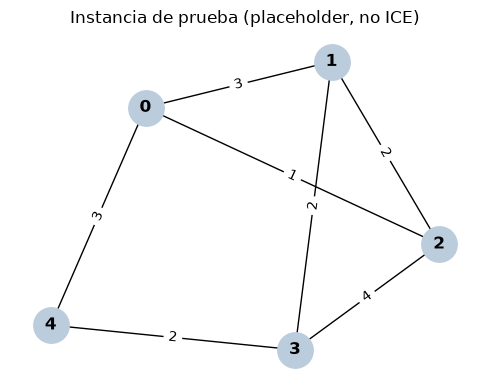

In [2]:
# Grafo placeholder: 5 nodos, 7 aristas ponderadas. NO es la red del ICE.
G = nx.Graph()
G.add_weighted_edges_from([
    (0, 1, 3.0),
    (1, 2, 2.0),
    (2, 3, 4.0),
    (3, 4, 2.0),
    (4, 0, 3.0),
    (0, 2, 1.0),
    (1, 3, 2.0),
])

print(f"nodos = {G.number_of_nodes()}, aristas = {G.number_of_edges()}")
print("peso total de aristas =", sum(d['weight'] for *_ , d in G.edges(data=True)))

pos = nx.spring_layout(G, seed=7)
fig, ax = plt.subplots(figsize=(5, 4))
nx.draw_networkx(G, pos, ax=ax, node_color="#bcd", node_size=650, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, ax=ax,
    edge_labels={(u, v): f"{d['weight']:g}" for u, v, d in G.edges(data=True)})
ax.set_title("Instancia de prueba (placeholder, no ICE)")
ax.axis("off")
plt.tight_layout(); plt.show()

*(grafica generada con la ayuda de Claude Opus 4.8)*

## 3. La matriz `Q` explicita

Como las variables son binarias, $x_i^2 = x_i$: los terminos lineales se absorben en
la diagonal y todo $f(x)$ se escribe como una unica forma cuadratica
$f(x) = x^{\mathsf T} Q\, x$ sin termino lineal separado.

Con la convencion simetrica ($Q_{ij} = Q_{ji}$):

$$Q_{ii} = -\!\!\sum_{j:(i,j)\in E} w_{ij} \quad(\text{grado ponderado, en negativo}) \qquad Q_{ij} = Q_{ji} = w_{ij}$$

In [3]:
def build_qubo_matrix(graph: nx.Graph, weight: str = "weight") -> NDArray[np.float64]:
    """
    Construye la matriz QUBO simetrica Q para Max-Cut ponderado.

    Convencion (fijada para todo el proyecto):
        f(x) = xᵀ Q x   se MINIMIZA
        C(x) = -f(x)    es el valor del corte, se MAXIMIZA

        Q_ii = -(grado ponderado del nodo i)
        Q_ij = Q_ji = w_ij   por cada arista (i, j)

    Los nodos se indexan por su posicion en sorted(graph.nodes): la fila/columna k
    de Q corresponde a node_list[k]. Ese mapeo se devuelve aparte (build_index_map).
    """
    nodes = sorted(graph.nodes)
    index = {node: k for k, node in enumerate(nodes)}
    n = len(nodes)

    Q = np.zeros((n, n), dtype=np.float64)

    for u, v, data in graph.edges(data=True):
        w = float(data.get(weight, 1.0))
        i, j = index[u], index[v]
        # Fuera de diagonal: +w_ij (simetrico)
        Q[i, j] += w
        Q[j, i] += w
        # Diagonal: -w_ij en cada extremo (grado ponderado negativo)
        Q[i, i] -= w
        Q[j, j] -= w

    return Q


def build_index_map(graph: nx.Graph) -> tuple[list, dict]:
    """
    Devuelve (node_list, node_to_index).

    node_list[k]  -> nombre del nodo en la fila/columna k de Q y en la posicion k
                     del bitstring.
    node_to_index -> inverso.

    Sin este mapeo, un bitstring '01101' no puede traducirse de vuelta a que nodo
    quedo en que isla.
    """
    node_list = sorted(graph.nodes)
    node_to_index = {node: k for k, node in enumerate(node_list)}
    return node_list, node_to_index


Q = build_qubo_matrix(G)
node_list, node_to_index = build_index_map(G)
print("node_list =", node_list)
print("Q =\n", Q)
print("¿Q simetrica?", np.allclose(Q, Q.T))

node_list = [0, 1, 2, 3, 4]
Q =
 [[-7.  3.  1.  0.  3.]
 [ 3. -7.  2.  2.  0.]
 [ 1.  2. -7.  4.  0.]
 [ 0.  2.  4. -8.  2.]
 [ 3.  0.  0.  2. -5.]]
¿Q simetrica? True


### 3.1 Verificacion minima a mano (una arista)

Antes de confiar en nada, se reproduce en codigo el caso mas pequeño: dos nodos, una
arista de peso $w$.

$$Q = \begin{bmatrix} -w & w \\ w & -w \end{bmatrix} \qquad f(x) = x^{\mathsf T} Q\, x = -w\,x_0 - w\,x_1 + 2w\,x_0 x_1$$

- $x=(1,0)\Rightarrow f=-w\Rightarrow C=w$ → corte 1 ✓
- $x=(1,1)\Rightarrow f=0\Rightarrow C=0$ → corte 0 ✓
- $x=(0,0)\Rightarrow f=0\Rightarrow C=0$ → corte 0 ✓

Si el codigo no reproduce estos tres numeros, hay un error de signo y se detiene
todo hasta arreglarlo.

In [4]:
# Instancia de 2 nodos con peso simbolico w = 5.0
w = 5.0
G2 = nx.Graph()
G2.add_weighted_edges_from([(0, 1, w)])
Q2 = build_qubo_matrix(G2)

expected = np.array([[-w, w], [w, -w]])
assert np.allclose(Q2, expected), f"Q2 no coincide con la matriz a mano:\n{Q2}"

def f_of(x, Qm):
    x = np.asarray(x, dtype=float)
    return float(x @ Qm @ x)

checks = {(1, 0): (-w, w), (1, 1): (0.0, 0.0), (0, 0): (0.0, 0.0)}
print("Q(2 nodos) =\n", Q2, "\n")
for x, (f_exp, C_exp) in checks.items():
    f_val = f_of(x, Q2) + 0.0   # +0.0 normaliza -0.0 -> +0.0 en la impresion
    C_val = -f_val + 0.0
    assert abs(f_val - f_exp) < 1e-12 and abs(C_val - C_exp) < 1e-12, f"fallo en x={x}"
    print(f"  x={x}: f={f_val:+.1f}  C={C_val:+.1f}   (esperado f={f_exp:+.1f}, C={C_exp:+.1f}) ✓")

print("\n✓ Verificacion a mano de 2 nodos reproducida en codigo.")

Q(2 nodos) =
 [[-5.  5.]
 [ 5. -5.]] 

  x=(1, 0): f=-5.0  C=+5.0   (esperado f=-5.0, C=+5.0) ✓
  x=(1, 1): f=+0.0  C=+0.0   (esperado f=+0.0, C=+0.0) ✓
  x=(0, 0): f=+0.0  C=+0.0   (esperado f=+0.0, C=+0.0) ✓

✓ Verificacion a mano de 2 nodos reproducida en codigo.


## 4. Evaluacion de `f` y de `C`

Dos funciones espejo ($C = -f$) mas `cut_value`, el verificador comun por XOR
que no depende de la matriz.

In [ ]:
def qubo_energy(x: NDArray[np.float64], Q: NDArray[np.float64]) -> float:
    """f(x) = xᵀ Q x."""
    return float(x @ Q @ x)


def cut_value_from_vector(x: NDArray[np.float64], Q: NDArray[np.float64]) -> float:
    """C(x) = -f(x)."""
    return -qubo_energy(x, Q)


def cut_value(bitstring: str, graph: nx.Graph,
              node_list: list, weight: str = "weight") -> float:
    """Valor del corte por XOR arista a arista, independiente de Q."""
    pos = {node: k for k, node in enumerate(node_list)}
    total = 0.0
    for u, v, data in graph.edges(data=True):
        w = float(data.get(weight, 1.0))
        bu, bv = int(bitstring[pos[u]]), int(bitstring[pos[v]])
        total += w * (bu ^ bv)
    return total


demo_bits = "10110"
x_demo = np.array([int(b) for b in demo_bits], dtype=float)
print(f"bitstring {demo_bits}: f = {qubo_energy(x_demo, Q):+.1f}, "
      f"C_via_Q = {cut_value_from_vector(x_demo, Q):+.1f}, "
      f"C_via_XOR = {cut_value(demo_bits, G, node_list):+.1f}")

### 4.1 Prueba de consistencia entre los dos caminos

Test de regresion: confirma que matriz `Q` y verificador XOR hablan del mismo
problema.

In [ ]:
def assert_paths_agree(graph: nx.Graph, Q: NDArray[np.float64],
                       node_list: list, n_samples: int = 200, seed: int = 0) -> None:
    """Verifica cut_value_from_vector(x, Q) == cut_value(bitstring, ...) en bitstrings aleatorios."""
    rng = np.random.default_rng(seed)
    n = len(node_list)
    for _ in range(n_samples):
        bits = rng.integers(0, 2, size=n)
        x = bits.astype(np.float64)
        bitstring = "".join(str(b) for b in bits)

        via_matrix = cut_value_from_vector(x, Q)
        via_xor = cut_value(bitstring, graph, node_list)

        assert abs(via_matrix - via_xor) < 1e-9, (
            f"DISCREPANCIA en {bitstring}: matriz={via_matrix:.6f} vs XOR={via_xor:.6f}")
    print(f"✓ {n_samples} bitstrings: matriz Q y verificador XOR coinciden.")


assert_paths_agree(G, Q, node_list, n_samples=500)

## 5. Verificacion por fuerza bruta

Solo como verificador de que `Q` es correcta ($\min f = -\max C$), no como
linea base. Para n pequeño ($2^n$ enumerable) es viable enumerar todo.

In [ ]:
def brute_force_maxcut(graph: nx.Graph, Q: NDArray[np.float64], node_list: list) -> dict:
    """Enumera las 2^n particiones y devuelve el optimo exacto. Solo para n <= 22."""
    n = len(node_list)
    if n > 22:
        raise ValueError(f"n={n} demasiado grande para fuerza bruta (2^{n}).")

    best_C = -np.inf
    optimal_bits: list[str] = []

    for bits in product((0, 1), repeat=n):
        x = np.array(bits, dtype=np.float64)
        C = cut_value_from_vector(x, Q)
        if C > best_C + 1e-12:
            best_C = C
            optimal_bits = ["".join(map(str, bits))]
        elif abs(C - best_C) < 1e-12:
            optimal_bits.append("".join(map(str, bits)))

    return {"C_max": best_C, "optimal_bits": optimal_bits, "f_min": -best_C}


bf = brute_force_maxcut(G, Q, node_list)
print("C_max =", bf["C_max"], "| optimal_bits =", bf["optimal_bits"])

assert abs(bf["f_min"] + bf["C_max"]) < 1e-9
print("✓ f_min == -C_max: formulacion verificada.")

## 6. Puente hacia el circuito: del QUBO al Hamiltoniano de Ising

Con el cambio de variable estandar $x_i = (1-z_i)/2$, $C(x)$ se convierte en un
Hamiltoniano de Ising:

$$H_C = \sum_{(i,j)\in E} \frac{w_{ij}}{2}\, Z_i Z_j$$

Cada arista se traduce en una rotacion `zz_phase` escalada por su peso $w_{ij}$.
Abajo se comprueba que esta forma da el mismo corte que `cut_value`.

In [ ]:
def ising_coefficients(graph: nx.Graph, node_list: list, weight: str = "weight") -> list[dict]:
    """Coeficientes de H_C = sum (w_ij/2) Z_i Z_j, por arista."""
    pos = {node: k for k, node in enumerate(node_list)}
    terms = []
    for u, v, data in graph.edges(data=True):
        w = float(data.get(weight, 1.0))
        i, j = pos[u], pos[v]
        terms.append({"qubits": (i, j), "w_ij": w, "coeff_ZZ": w / 2.0})
    return terms


def cut_value_from_ising(bitstring: str, graph: nx.Graph, node_list: list,
                         weight: str = "weight") -> float:
    """C(x) = sum w_ij (1 - z_i z_j)/2, con z = 1 - 2x."""
    pos = {node: k for k, node in enumerate(node_list)}
    total = 0.0
    for u, v, data in graph.edges(data=True):
        w = float(data.get(weight, 1.0))
        zi = 1 - 2 * int(bitstring[pos[u]])
        zj = 1 - 2 * int(bitstring[pos[v]])
        total += w * (1 - zi * zj) / 2.0
    return total


terms = ising_coefficients(G, node_list)
for t in terms:
    print(f"  Z_{t['qubits'][0]} Z_{t['qubits'][1]}   w_ij={t['w_ij']:g}   coeff={t['coeff_ZZ']:g}")

n = len(node_list)
mismatch = sum(
    1 for bits in product((0, 1), repeat=n)
    if abs(cut_value("".join(map(str, bits)), G, node_list)
           - cut_value_from_ising("".join(map(str, bits)), G, node_list)) > 1e-9
)
assert mismatch == 0
print(f"✓ XOR e Ising coinciden en los {2**n} bitstrings.")

## 7. Nota sobre penalizacion (Capa 2, fuera de este nucleo)

Max-Cut es no restringido, asi que aqui no hay terminos de penalizacion que
agregar. Las restricciones fisicas (balance generacion-demanda, cargas criticas)
irian en una Capa 2 aparte, fuera del alcance de este notebook.

## Visualizacion de la particion optima

El corte maximo hecho tangible: los nodos coloreados por isla y las aristas cortadas
resaltadas. (Sobre la instancia placeholder, solo para ilustrar la formulacion.)

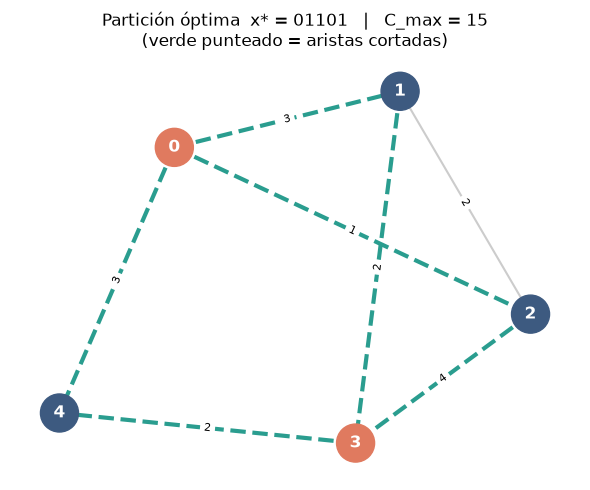

Isla A (x=0): [0, 3]
Isla B (x=1): [1, 2, 4]


In [9]:
x_star = bf["optimal_bits"][0]
island = {node_list[k]: int(x_star[k]) for k in range(len(node_list))}

colors = ["#e07a5f" if island[nd] == 0 else "#3d5a80" for nd in G.nodes()]
cut_edges = [(u, v) for u, v in G.edges() if island[u] != island[v]]
uncut_edges = [(u, v) for u, v in G.edges() if island[u] == island[v]]

fig, ax = plt.subplots(figsize=(6, 5))
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=750)
nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=uncut_edges, edge_color="#cccccc", width=1.5)
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=cut_edges, edge_color="#2a9d8f",
                       width=3.0, style="dashed")
nx.draw_networkx_edge_labels(G, pos, ax=ax,
    edge_labels={(u, v): f"{d['weight']:g}" for u, v, d in G.edges(data=True)}, font_size=8)
ax.set_title(f"Particion optima  x* = {x_star}   |   C_max = {bf['C_max']:g}\n"
             f"(verde punteado = aristas cortadas)")
ax.axis("off")
plt.tight_layout(); plt.show()

print(f"Isla A (x=0): {[nd for nd in node_list if island[nd]==0]}")
print(f"Isla B (x=1): {[nd for nd in node_list if island[nd]==1]}")

*(grafica generada con la ayuda de Claude Opus 4.8)*

## 8. Resumen

Chequeo de formulacion listo: matriz Q, verificador XOR, fuerza bruta y puente a
Ising, todo consistente entre si.

In [ ]:
print(f"bitstring optimo = {bf['optimal_bits'][0]}, C_max = {bf['C_max']:g}, r = 1.0000")
print()
for item in [
    "matriz Q y build_index_map",
    "verificacion a mano de 2 nodos",
    "matriz Q == verificador XOR",
    "fuerza bruta: f_min == -C_max",
    "convencion de signos escrita",
    "puente Ising verificado",
]:
    print(f"  [x] {item}")